# RoPE旋转位置嵌入

根据上一章我们知道, 当前的架构并不能处理涉及 token 位置的任务, 换句话说就是 `Q/K` 不带位置信息, 于是我们需要给其加上位置编码 `Positional Embedding`, 以此让模型学到位置信息

什么是位置编码? 实际上就是给模型的 `Q/K` 加上位置信息. 目标就是让模型做注意力计算时, 分数能带上参与计算的两个 token 相隔多远这个信息.

在 Attention Is All You Need 原论文中实际上用的是正余弦位置编码的方案, 而在现代实践中更加常用和主流的方案是RoPE旋转位置编码, 所以我们主要实现后者

明确了当前架构的缺陷和我选择RoPE的动机, 下一个问题就是: 什么是RoPE?

RoPE是 Rotary Position Embedding 的缩写, 其核心思想就是用旋转的角度表示相对位置.

在线性代数中, 想给一个二维向量旋转, 只需要给其乘上旋转矩阵

$$R(\theta) =
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}$$

RoPE 其实就是给每一对相邻的维度 $(x_{2i}, x_{2i+1})$ 做二维旋转

$$
\begin{bmatrix}
x_{2i}^{'}\\
x_{2i+1}^{'}
\end{bmatrix}
=
\begin{bmatrix}
\cos\theta & -\sin\theta \\
\sin\theta & \cos\theta
\end{bmatrix}
\begin{bmatrix}
x_{2i} \\
x_{2i+1}
\end{bmatrix}$$

数学形式搞清楚了. 现在要用 Pytorch 代码表达, 并进行工程上的优化.



In [ ]:
import torch
from torch import nn
import torch.nn.functional as F

from sklearn.metrics import classification_report

class RoPEAttention(nn.Module):
    def __init__(self, vocab_size, output_dim, d_model, num_heads): # 加入num_heads参数设置头数量
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads # 按照num_heads切分d_model
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, output_dim)
        self.attn_w = None
    
    def _rotate_half(self, x): # 新增
        # x: (batch, num_heads, seq_len, d_k)
        x1 = x[..., ::2]
        x2 = x[..., 1::2]
        return torch.stack((-x2, x1), dim=-1).flatten(-2)

    def _rope(self, q, k, base=10000): # 新增
        # q, k: (batch, num_heads, seq_len, d_k)
        seq_len = q.size(-2)
        freqs = torch.arange(0, self.d_k, 2, device=q.device) / self.d_k
        freqs = base ** freqs                                           # (d_k/2,)
        angles = torch.arange(seq_len, device=q.device)[:, None] / freqs[None, :]  # (seq_len, d_k/2)
        sin = angles.sin().repeat_interleave(2, dim=-1)[None, None]   # (1, 1, seq_len, d_k)
        cos = angles.cos().repeat_interleave(2, dim=-1)[None, None]   # (1, 1, seq_len, d_k)
        return q * cos + self._rotate_half(q) * sin, \
            k * cos + self._rotate_half(k) * sin
    
    def forward(self, x):
        """
        x: (batch, seq_len)
        """
        batch_size = x.size(0)
        x = self.embedding(x)  # (batch, seq_len, d_model)
        Q = self.w_q(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.w_k(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.w_v(x).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        Q, K = self._rope(Q, K) # 应用RoPE
        # score: (batch, query, key) --- 序列内各位置之间的注意力, query为token位置, key为看的那个位置
        score = Q @ K.transpose(-2, -1) / self.d_k ** 0.5
        attn_w = torch.softmax(score, dim=-1)
        self.attn_w = attn_w.detach()
        output = attn_w @ V # (batch, num_heads, seq_len, d_k)
        output = output.transpose(1, 2).reshape(batch_size, -1, self.d_model) # 将多头的输出拼接回原来的维度
        return self.out(output) # (batch, seq_len, output_dim)


In [10]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Microsoft YaHei"
plt.rcParams["axes.unicode_minus"] = False

def plot_attention(attn_w, tokens, title="Head", cmap="Blues"):
    # attn_w: (num_heads, T, T)
    
    num_heads = attn_w.shape[0]
    seq_len = attn_w.shape[1]
    attn_w = attn_w.detach().cpu().float()

    cell = seq_len * 0.5 + 0.5
    fig, axes = plt.subplots(2, 2, figsize=(cell * 2, cell * 2), constrained_layout=True)

    for n in range(4):
        ax = axes[n // 2][n % 2]
        if n < num_heads:
            im = ax.imshow(attn_w[n], cmap=cmap, vmin=0, vmax=1)
            ax.set_xticks(range(seq_len))
            ax.set_xticklabels(tokens, rotation=45, ha="right", fontsize=7)
            ax.set_yticks(range(seq_len))
            ax.set_yticklabels(tokens, fontsize=7)
            ax.set_title(f"{title} Head-{n}", fontsize=9)
            for i in range(seq_len):
                for j in range(seq_len):
                    val = attn_w[n, i, j].item()
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                            fontsize=6, color="white" if val > 0.6 else "black")
        else:
            ax.axis('off')

    plt.colorbar(im, ax=axes, fraction=0.02, pad=0.04)
    plt.show()

# 实验1 指针检索任务

## 1. 数据集构建

同上一章实验2

In [4]:
def get_seq_batch(batch, seq_len, vocab_size):
    seq = torch.randint(0, vocab_size, (batch, seq_len), dtype=torch.long)
    idx = torch.randint(0, seq_len, (batch,), dtype=torch.long)
    Q = torch.full((batch, 1), vocab_size, dtype=torch.long)  # 目标 token 是 vocab_size（即 high）这个特殊 token
    x = torch.cat([seq, Q, idx.unsqueeze(1)], dim=1)  # (batch, seq_len)
    y = seq[torch.arange(batch), idx]
    return x, y

get_seq_batch(2, 5, 10)


(tensor([[ 3,  4,  4,  6,  1, 10,  3],
         [ 4,  6,  4,  0,  3, 10,  1]]),
 tensor([6, 6]))

## 2. 模型训练

超参数设置为:
| vocab_size | d_model | num_heads | lr | train_steps |
|-|-|-|-|-|
| 100 | 32 | 4 | 0.01 | 200 |

In [5]:
epochs = 200

model = RoPEAttention(vocab_size=101, output_dim=100, d_model=16, num_heads=4)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

model.train()
for i in range(epochs):
    train_x, train_y = get_seq_batch(1024, 10, 100)
    optimizer.zero_grad()
    pred = model(train_x)[:, -1, :]
    loss = criterion(pred, train_y)
    loss.backward()
    optimizer.step()
    if (i+1) % 10 == 0:
        print(f"Epoch {i+1}, Loss: {loss.item():.4f}")

Epoch 10, Loss: 4.5814
Epoch 20, Loss: 4.4969
Epoch 30, Loss: 4.2908
Epoch 40, Loss: 3.8105
Epoch 50, Loss: 2.8903
Epoch 60, Loss: 2.0920
Epoch 70, Loss: 1.5022
Epoch 80, Loss: 0.9636
Epoch 90, Loss: 0.4776
Epoch 100, Loss: 0.1962
Epoch 110, Loss: 0.0963
Epoch 120, Loss: 0.0399
Epoch 130, Loss: 0.0265
Epoch 140, Loss: 0.0205
Epoch 150, Loss: 0.0131
Epoch 160, Loss: 0.0153
Epoch 170, Loss: 0.0083
Epoch 180, Loss: 0.0060
Epoch 190, Loss: 0.0072
Epoch 200, Loss: 0.0062


## 3. 评估实验

Pointer Retrieval Classification Report
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        42
           1     1.0000    1.0000    1.0000        42
           2     1.0000    1.0000    1.0000        45
           3     1.0000    1.0000    1.0000        36
           4     1.0000    1.0000    1.0000        53
           5     1.0000    1.0000    1.0000        39
           6     1.0000    1.0000    1.0000        32
           7     1.0000    1.0000    1.0000        35
           8     1.0000    1.0000    1.0000        38
           9     1.0000    1.0000    1.0000        35
          10     1.0000    1.0000    1.0000        42
          11     1.0000    1.0000    1.0000        47
          12     1.0000    1.0000    1.0000        46
          13     1.0000    1.0000    1.0000        44
          14     1.0000    1.0000    1.0000        29
          15     1.0000    1.0000    1.0000        45
          16     1.0000    1.0000    1.00

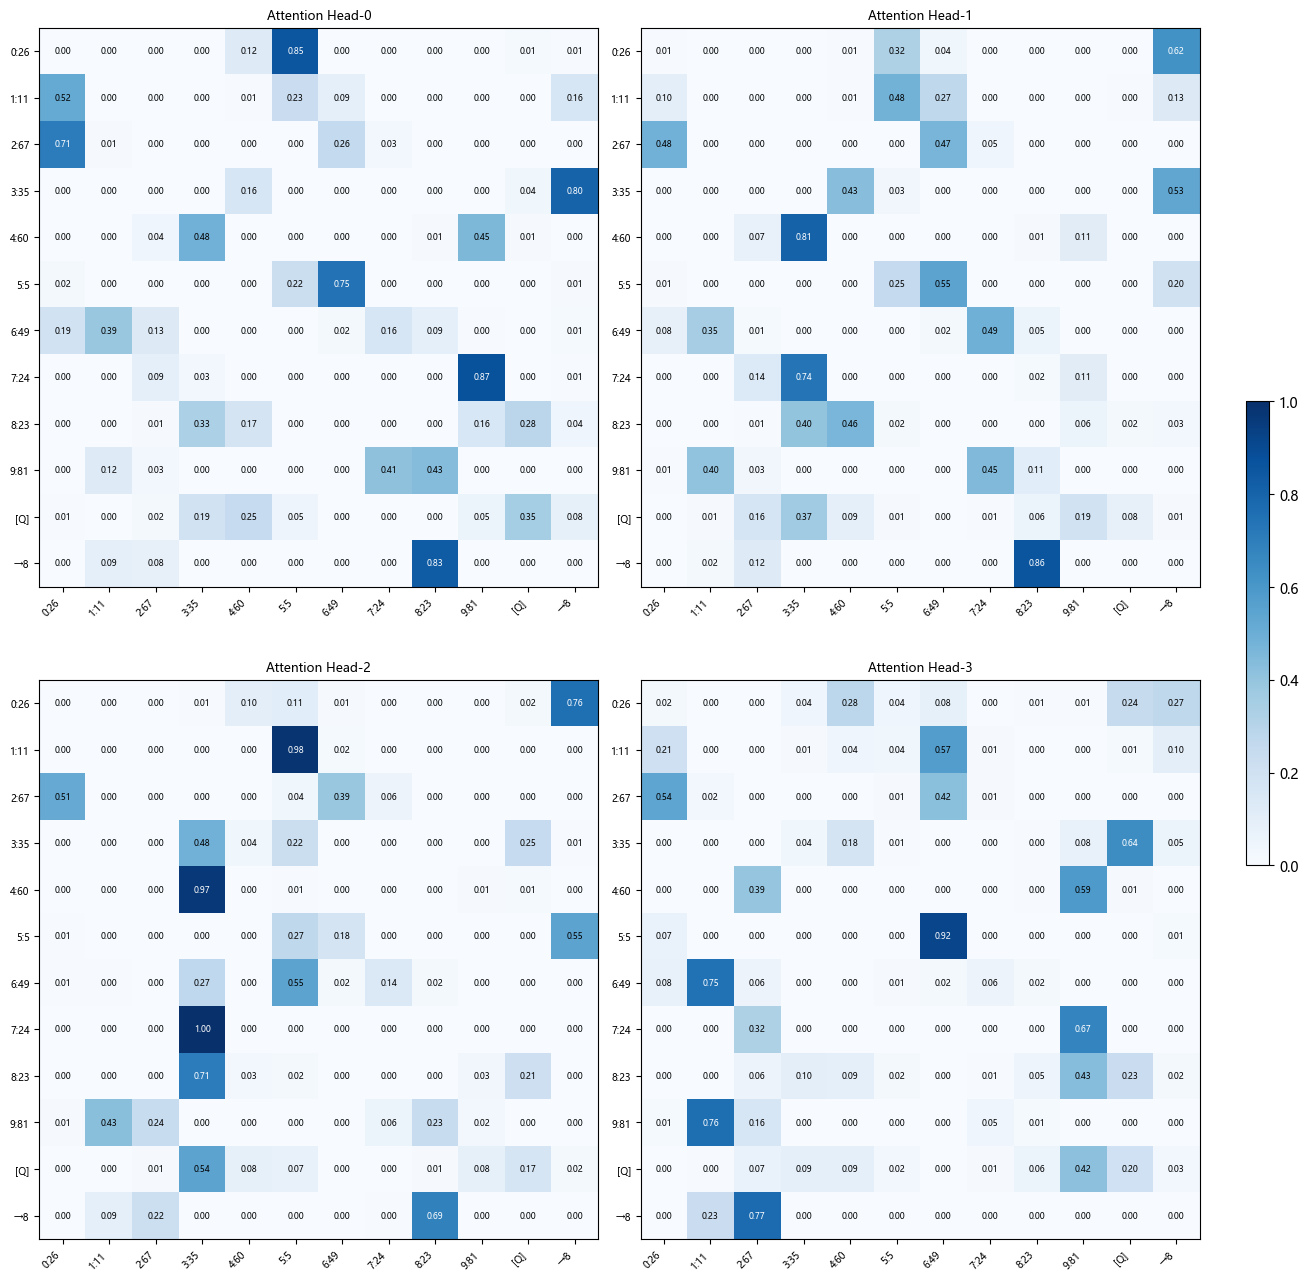

In [ ]:
model.eval()
with torch.no_grad():
    eval_x, eval_y = get_seq_batch(4096, 10, 100)
    eval_logits = model(eval_x)[:, -1, :]   # (batch, 100)
    eval_pred = eval_logits.argmax(dim=-1)  # (batch,)

    y_true = eval_y.cpu().numpy()
    y_pred = eval_pred.cpu().numpy()

    print("Pointer Retrieval Classification Report")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))

    test_x, test_y = get_seq_batch(4, 10, 100)
    values = test_x[0, :10].tolist()
    q_idx = test_x[0, -1].item()
    query_labels = [f"{i}:{v}" for i, v in enumerate(values)] + ["[Q]", f"→{q_idx}"]

    pred = model(test_x)[:, -1, :]
    for i in range(test_x.size(0)):
        print(f"input : {test_x[i].tolist()}")
        print(f"pred  : {pred[i].argmax(dim=-1).item()}")
        print(f"target: {test_y[i].item()}")
        print("-" * 30)

    plot_attention(model.attn_w[0], tokens=query_labels, title="Attention")